In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

base_dir = Path.cwd().parent
raw_dir = base_dir / "data" / "raw"
processed_dir = base_dir / "data" / "processed"
recommendations_path = raw_dir / "recommendations.csv"

In [3]:
recommendations_sample = pd.read_csv(
    recommendations_path,
    nrows=100_000
)

print(recommendations_sample.shape)
print(recommendations_sample.head())
print(recommendations_sample.dtypes)

(100000, 8)
    app_id  helpful  funny        date  is_recommended  hours  user_id  \
0   975370        0      0  2022-12-12            True   36.3    51580   
1   304390        4      0  2017-02-17           False   11.5     2586   
2  1085660        2      0  2019-11-17            True  336.5   253880   
3   703080        0      0  2022-09-23            True   27.4   259432   
4   526870        0      0  2021-01-10            True    7.9    23869   

   review_id  
0          0  
1          1  
2          2  
3          3  
4          4  
app_id              int64
helpful             int64
funny               int64
date                  str
is_recommended       bool
hours             float64
user_id             int64
review_id           int64
dtype: object


#### 일별 추천 분석

In [4]:
daily_parts = []

for chunk in pd.read_csv(
    recommendations_path,
    chunksize=200_000
):
    chunk["date"] = pd.to_datetime(
        chunk["date"],
        errors="coerce"
    )

    chunk["recommended"] = (
        chunk["is_recommended"].astype(int)
    )

    part = chunk.groupby(
        chunk["date"].dt.date
    ).agg(
        review_count=("review_id", "count"),
        recommended_count=("recommended", "sum"),
        hours_sum=("hours", "sum")
    ).reset_index()

    daily_parts.append(part)

print("Chunks processed:", len(daily_parts))

Chunks processed: 206


In [5]:
daily_analysis = pd.concat(
    daily_parts,
    ignore_index=True
)

daily_analysis = daily_analysis.groupby("date").agg(
    review_count=("review_count", "sum"),
    recommended_count=("recommended_count", "sum"),
    hours_sum=("hours_sum", "sum")
).reset_index()

daily_analysis["recommend_rate"] = (
    daily_analysis["recommended_count"] /
    daily_analysis["review_count"]
)

daily_analysis["avg_hours"] = (
    daily_analysis["hours_sum"] /
    daily_analysis["review_count"]
)

print(daily_analysis.head())
print(daily_analysis.shape)

         date  review_count  recommended_count  hours_sum  recommend_rate  \
0  2010-10-15            57                 54     4784.4        0.947368   
1  2010-10-16            91                 88    11983.7        0.967033   
2  2010-10-17            32                 32     3275.5        1.000000   
3  2010-10-18            37                 35     2891.2        0.945946   
4  2010-10-19            20                 20     1793.3        1.000000   

    avg_hours  
0   83.936842  
1  131.689011  
2  102.359375  
3   78.140541  
4   89.665000  
(4450, 6)


#### 월별 추천 분석

In [6]:
daily_analysis["date"] = pd.to_datetime(
    daily_analysis["date"]
)

daily_analysis["month"] = (
    daily_analysis["date"].dt.to_period("M")
)

monthly_analysis = daily_analysis.groupby("month").agg(
    review_count=("review_count", "sum"),
    recommended_count=("recommended_count", "sum"),
    hours_sum=("hours_sum", "sum")
).reset_index()

monthly_analysis["recommend_rate"] = (
    monthly_analysis["recommended_count"] /
    monthly_analysis["review_count"]
)

monthly_analysis["avg_hours"] = (
    monthly_analysis["hours_sum"] /
    monthly_analysis["review_count"]
)

print(monthly_analysis.head())
print(monthly_analysis.tail())

     month  review_count  recommended_count  hours_sum  recommend_rate  \
0  2010-10           363                352    35382.9        0.969697   
1  2010-11          4331               4211   432155.9        0.972293   
2  2010-12          7507               7320   717370.1        0.975090   
3  2011-01          3302               3182   299717.7        0.963658   
4  2011-02          2129               2046   228718.6        0.961015   

    avg_hours  
0   97.473554  
1   99.782013  
2   95.560157  
3   90.768534  
4  107.430061  
       month  review_count  recommended_count    hours_sum  recommend_rate  \
142  2022-08        716011             615734   61073630.9        0.859950   
143  2022-09        669102             557864   55657650.4        0.833750   
144  2022-10        729496             585477   60395464.9        0.802577   
145  2022-11       1282247            1132940  103692352.9        0.883558   
146  2022-12       1002583             836239   73531795.7        0.8

In [7]:
print(
    monthly_analysis[
        [
            "month",
            "review_count",
            "recommend_rate",
            "avg_hours"
        ]
    ]
)

       month  review_count  recommend_rate   avg_hours
0    2010-10           363        0.969697   97.473554
1    2010-11          4331        0.972293   99.782013
2    2010-12          7507        0.975090   95.560157
3    2011-01          3302        0.963658   90.768534
4    2011-02          2129        0.961015  107.430061
..       ...           ...             ...         ...
142  2022-08        716011        0.859950   85.297057
143  2022-09        669102        0.833750   83.182610
144  2022-10        729496        0.802577   82.790673
145  2022-11       1282247        0.883558   80.867690
146  2022-12       1002583        0.834085   73.342352

[147 rows x 4 columns]


#### 추천 여부와 플레이 시간

In [8]:
recommendation_parts = []

for chunk in pd.read_csv(
    recommendations_path,
    chunksize=200_000,
    usecols=["is_recommended", "hours"]
):
    part = chunk.groupby("is_recommended").agg(
        review_count=("hours", "count"),
        hours_sum=("hours", "sum")
    ).reset_index()

    recommendation_parts.append(part)

recommendation_analysis = pd.concat(
    recommendation_parts,
    ignore_index=True
)

recommendation_analysis = (
    recommendation_analysis
    .groupby("is_recommended")
    .agg(
        review_count=("review_count", "sum"),
        hours_sum=("hours_sum", "sum")
    )
    .reset_index()
)

recommendation_analysis["avg_hours"] = (
    recommendation_analysis["hours_sum"] /
    recommendation_analysis["review_count"]
)

print(recommendation_analysis)

   is_recommended  review_count     hours_sum   avg_hours
0           False       5850396  4.732594e+08   80.893559
1            True      35304398  3.667005e+09  103.868221


#### 시각화

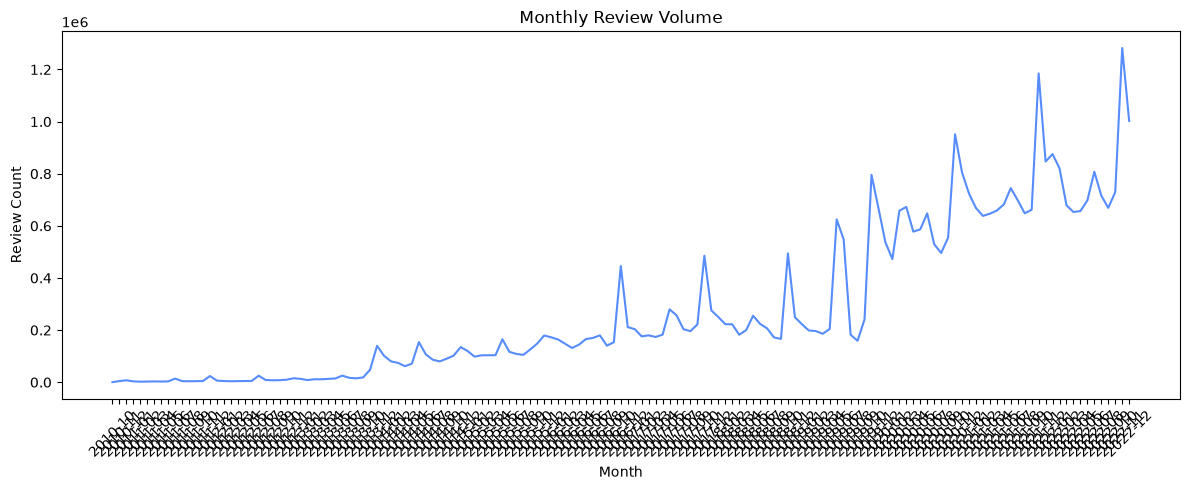

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_analysis["month"].astype(str),
    monthly_analysis["review_count"]
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Review Count")
plt.title("Monthly Review Volume")
plt.tight_layout()
plt.show()

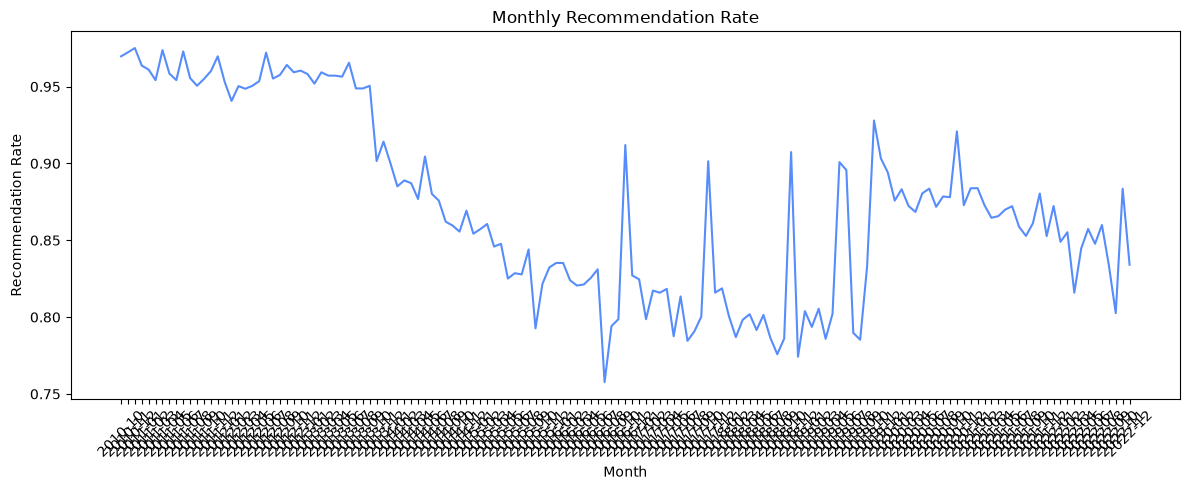

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_analysis["month"].astype(str),
    monthly_analysis["recommend_rate"]
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Recommendation Rate")
plt.title("Monthly Recommendation Rate")
plt.tight_layout()
plt.show()

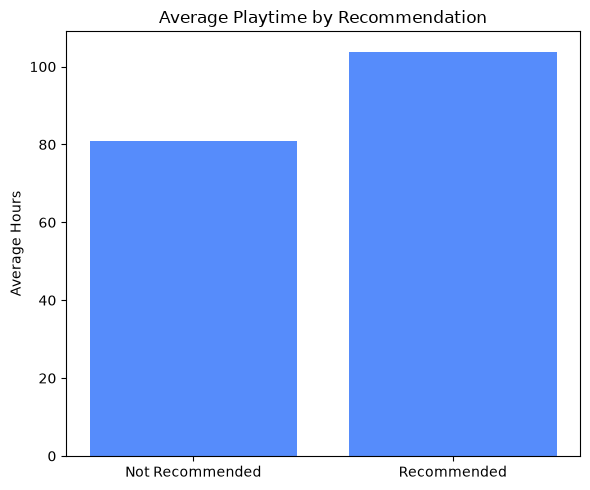

In [11]:
labels = ["Not Recommended", "Recommended"]

plt.figure(figsize=(6, 5))

plt.bar(
    labels,
    recommendation_analysis["avg_hours"]
)

plt.ylabel("Average Hours")
plt.title("Average Playtime by Recommendation")
plt.tight_layout()
plt.show()

#### 결과 저장

In [12]:
monthly_analysis.to_csv(
    processed_dir / "monthly_recommendation_analysis.csv",
    index=False
)

recommendation_analysis.to_csv(
    processed_dir / "recommendation_summary.csv",
    index=False
)

print("Analysis results saved.")

Analysis results saved.
